# 南米 ADM2 主分析（v2 掘削ポリゴン版）

In [1]:
#%pip install econml

In [1]:

# 基本設定・ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# プロジェクトルートの検出とデータパス設定
CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
parquet_name = 'analysis_df_v2_with_icews.parquet'
base_dir = None
for cand in CANDIDATES:
    if (cand / 'processed' / parquet_name).exists():
        base_dir = cand
        break
if base_dir is None:
    raise FileNotFoundError('processed/analysis_df_v2_with_icews.parquet が見つかりません。ルートを確認してください。')

DATA_DIR = base_dir / 'processed'
DATA_PATH = DATA_DIR / parquet_name
RANDOM_STATE = 42

In [2]:

# データ読み込み（v2処置 + ICEWS統合済み）
analysis_df = pd.read_parquet(DATA_PATH)
print(f"Loaded: {analysis_df.shape[0]} rows, {analysis_df.shape[1]} cols")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(analysis_df.head(5))


Loaded: 75969 rows, 106 cols


,GID_2,year,ruggedness,population_count,road_length_tertiary_roads,road_length_secondary_roads,road_length_primary_roads,road_length_local_roads,road_length_highways,population_density,elevation,viirs,wind_potential,solar_potential,landcover_MODIS_urban_builtup,landcover_MODIS_savanna,landcover_MODIS_wetland,landcover_MODIS_forest,landcover_MODIS_water,landcover_MODIS_grassland,landcover_MODIS_cropland,landcover_MODIS_shrub,landcover_MODIS_barren,time_to_cities_mins,time_to_large_cities_mins,time_to_medium_cities_mins,time_to_ports_mins,time_to_airports_mins,forest_loss_count,forest_loss_sum,forest_loss_mean,has_capital,has_land_border,dist_geomcentr_to_capital_km,lon_geomcentr,lat_geomcentr,has_rivers_lakes,has_coasts,lon_popcentr,lat_popcentr,dist_popcentr_to_capital_km,has_flare,has_ports,has_int_airports,has_large_airports,has_medium_airports,GID_1,GID_0,area_sq_km,landcover_MODIS_urban_builtup_share,landcover_MODIS_savanna_share,landcover_MODIS_wetland_share,landcover_MODIS_forest_share,landcover_MODIS_water_share,landcover_MODIS_grassland_share,landcover_MODIS_cropland_share,landcover_MODIS_shrub_share,landcover_MODIS_barren_share,road_length_structural_flag,road_length_imputed_flag,time_to_cities_mins_structural_flag,time_to_cities_mins_imputed_flag,time_to_large_cities_mins_structural_flag,time_to_large_cities_mins_imputed_flag,time_to_medium_cities_mins_structural_flag,time_to_medium_cities_mins_imputed_flag,time_to_ports_mins_structural_flag,time_to_ports_mins_imputed_flag,time_to_airports_mins_structural_flag,time_to_airports_mins_imputed_flag,CC.EST,GE.EST,PV.EST,RL.EST,RQ.EST,VA.EST,institution_index,mine_site_count_v2,mine_area_km2_v2,mine_presence_v2,mine_presence_neighbor_v2,mine_presence_expanded_v2,tc_ppt,tc_pet,tc_aet,tc_def,tc_q,tc_tmax,tc_tmin,tc_vap,tc_vpd,tc_ws,tc_srad,tc_soil_mean,tc_swe_mean,tc_pdsi_mean,tc_tmean,epr_group_count_poly,epr_dom_share_cov,epr_frac_norm,epr_overlap_intensity,icews_event_count,icews_material_17_20_count,icews_high_conflict_count,icews_intensity_mean,icews_high_intensity_count_share_sa_year
0,ARG.1.100_1,2012,6732.596191,13596.339844,303311.625,0.0,12369.510742,0.0,0.0,8.743810,24.75642,0.136705,311.789032,9836.143555,8132194.0,8646025.0,4949884.5,0.000000,34749188.0,1.426693e+09,76602712.0,0.0,0.0,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,13646.330078,0.006397,0.0,0.0,116.268784,-59.226307,-35.524914,1.0,0.0,-59.358643,-35.488071,118.700424,0.0,0.0,0.0,0.0,0.0,ARG.1_1,ARG,1563.333008,0.005214,0.005543,0.003173,0.00000,0.022278,0.914680,0.049111,0.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,-0.245731,-0.084966,0.755316,-0.271374,-0.831479,0.247331,-0.071817,0.0,0.0,0.0,0,0,1355.232955,1211.965909,1014.025000,197.940909,296.719318,23.209830,10.656307,1.432204,0.755578,2.933551,188.440909,37.473011,0.0,-0.147121,16.933068,2.0,0.221142,0.296599,1.221142,2.0,0.0,0.0,2.350000,0.000000
1,ARG.1.100_1,2013,6732.596191,13779.962891,303311.625,0.0,12369.510742,0.0,0.0,8.861900,24.75642,0.162356,311.789032,9836.143555,8132194.0,12303202.0,7432259.0,0.000000,34749188.0,1.403603e+09,93553328.0,0.0,0.0,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,24909.259766,0.011676,0.0,0.0,116.268784,-59.226307,-35.524914,1.0,0.0,-59.358643,-35.488071,118.700424,0.0,0.0,0.0,0.0,0.0,ARG.1_1,ARG,1563.333008,0.005214,0.007888,0.004765,0.00000,0.022278,0.899876,0.059979,0.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,-0.223999,-0.171848,0.624557,-0.314306,-0.879585,0.212428,-0.125459,0.0,0.0,0.0,0,0,888.980682,1262.823864,827.497727,435.326136,99.461364,23.319044,9.855218,1.370550,0.786989,2.988078,200.192519,30.195739,0.0,1.506600,16.587131,2.0,0.221142,0.296599,1.221142,6.0,0.0,1.0,2.000000,0.000709
2,ARG.1.100_1,2014,6732.596191,13966.066406,303311.625,0.0,12369.510742,0.0,0.0,8.981586,24.75642,0.168650,311.789032,9836.143555,8132194.0,15961148.0,11045363.0,0.000000,34749188.0,1.385986e+09,103899168.0,0.0,0.0,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,35725.730469,0.016747,0.0,0.0,

In [3]:
# Outcome / treatment / covariates
df = analysis_df.copy()

y_col = "night_lights_ln001"
if y_col not in df.columns:
    df[y_col] = np.log(df["viirs"].astype(float) + 0.01)

y_wins_col = f"{y_col}_wins"
base_treatment_col = "mine_presence_expanded_v2"

exclude_cols = {
    "GID_2", "year", base_treatment_col, "GID_1", "GID_0", "viirs",
    "mine_presence_v2", "mine_presence_neighbor_v2",
    "mine_site_count_v2", "mine_area_km2_v2",
    "mine_presence", "mine_presence_neighbor", "mine_presence_expanded",
    "mine_site_count", "mine_area_km2",
    y_col,
}

X_cols = [
    c for c in df.columns
    if c not in exclude_cols and not c.endswith("_lag1")
]


/opt/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
# --- 1-year lag: use t-1 X/T to explain current Y ---

df0 = df.sort_values(["GID_2", "year"]).copy()

X_cols_lag = []
for c in X_cols:
    lag_c = f"{c}_lag1"
    if lag_c not in df0.columns:
        df0[lag_c] = df0.groupby("GID_2", sort=False)[c].shift(1)
    X_cols_lag.append(lag_c)

treatment_col = f"{base_treatment_col}_lag1"
if treatment_col not in df0.columns:
    df0[treatment_col] = df0.groupby("GID_2", sort=False)[base_treatment_col].shift(1)

req = [y_col, treatment_col] + X_cols_lag
before = len(df0)
df_lag = df0.dropna(subset=req).copy()
after = len(df_lag)

df_lag[treatment_col] = df_lag[treatment_col].astype(int)

X_cols = X_cols_lag
baseline_df = df_lag

print(f"1-year lag: drop rows {before-after} / {before}")
print("Lagged df shape:", df_lag.shape)
print("Lag years range:", df_lag["year"].min(), "-", df_lag["year"].max())
print("Treatment used:", treatment_col)


/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_96979/4234083727.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df0[treatment_col] = df0.groupby("GID_2", sort=False)[base_treatment_col].shift(1)


1-year lag: drop rows 8441 / 75969
Lagged df shape: (67528, 204)
Lag years range: 2013 - 2020
Treatment used: mine_presence_expanded_v2_lag1


In [6]:
df.head()

,GID_2,year,ruggedness,population_count,road_length_tertiary_roads,road_length_secondary_roads,road_length_primary_roads,road_length_local_roads,road_length_highways,population_density,elevation,viirs,wind_potential,solar_potential,landcover_MODIS_urban_builtup,landcover_MODIS_savanna,landcover_MODIS_wetland,landcover_MODIS_forest,landcover_MODIS_water,landcover_MODIS_grassland,landcover_MODIS_cropland,landcover_MODIS_shrub,landcover_MODIS_barren,time_to_cities_mins,time_to_large_cities_mins,time_to_medium_cities_mins,time_to_ports_mins,time_to_airports_mins,forest_loss_count,forest_loss_sum,forest_loss_mean,has_capital,has_land_border,dist_geomcentr_to_capital_km,lon_geomcentr,lat_geomcentr,has_rivers_lakes,has_coasts,lon_popcentr,lat_popcentr,dist_popcentr_to_capital_km,has_flare,has_ports,has_int_airports,has_large_airports,has_medium_airports,GID_1,GID_0,area_sq_km,landcover_MODIS_urban_builtup_share,landcover_MODIS_savanna_share,landcover_MODIS_wetland_share,landcover_MODIS_forest_share,landcover_MODIS_water_share,landcover_MODIS_grassland_share,landcover_MODIS_cropland_share,landcover_MODIS_shrub_share,landcover_MODIS_barren_share,road_length_structural_flag,road_length_imputed_flag,time_to_cities_mins_structural_flag,time_to_cities_mins_imputed_flag,time_to_large_cities_mins_structural_flag,time_to_large_cities_mins_imputed_flag,time_to_medium_cities_mins_structural_flag,time_to_medium_cities_mins_imputed_flag,time_to_ports_mins_structural_flag,time_to_ports_mins_imputed_flag,time_to_airports_mins_structural_flag,time_to_airports_mins_imputed_flag,CC.EST,GE.EST,PV.EST,RL.EST,RQ.EST,VA.EST,institution_index,mine_site_count_v2,mine_area_km2_v2,mine_presence_v2,mine_presence_neighbor_v2,mine_presence_expanded_v2,tc_ppt,tc_pet,tc_aet,tc_def,tc_q,tc_tmax,tc_tmin,tc_vap,tc_vpd,tc_ws,tc_srad,tc_soil_mean,tc_swe_mean,tc_pdsi_mean,tc_tmean,epr_group_count_poly,epr_dom_share_cov,epr_frac_norm,epr_overlap_intensity,icews_event_count,icews_material_17_20_count,icews_high_conflict_count,icews_intensity_mean,icews_high_intensity_count_share_sa_year,night_lights_ln001
0,ARG.1.100_1,2012,6732.596191,13596.339844,303311.625,0.0,12369.510742,0.0,0.0,8.743810,24.75642,0.136705,311.789032,9836.143555,8132194.0,8646025.0,4949884.5,0.000000,34749188.0,1.426693e+09,76602712.0,0.0,0.0,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,13646.330078,0.006397,0.0,0.0,116.268784,-59.226307,-35.524914,1.0,0.0,-59.358643,-35.488071,118.700424,0.0,0.0,0.0,0.0,0.0,ARG.1_1,ARG,1563.333008,0.005214,0.005543,0.003173,0.00000,0.022278,0.914680,0.049111,0.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,-0.245731,-0.084966,0.755316,-0.271374,-0.831479,0.247331,-0.071817,0.0,0.0,0.0,0,0,1355.232955,1211.965909,1014.025000,197.940909,296.719318,23.209830,10.656307,1.432204,0.755578,2.933551,188.440909,37.473011,0.0,-0.147121,16.933068,2.0,0.221142,0.296599,1.221142,2.0,0.0,0.0,2.350000,0.000000,-1.919330
1,ARG.1.100_1,2013,6732.596191,13779.962891,303311.625,0.0,12369.510742,0.0,0.0,8.861900,24.75642,0.162356,311.789032,9836.143555,8132194.0,12303202.0,7432259.0,0.000000,34749188.0,1.403603e+09,93553328.0,0.0,0.0,100.939156,117.554749,117.554749,124.676651,1440.0,2133324.0,24909.259766,0.011676,0.0,0.0,116.268784,-59.226307,-35.524914,1.0,0.0,-59.358643,-35.488071,118.700424,0.0,0.0,0.0,0.0,0.0,ARG.1_1,ARG,1563.333008,0.005214,0.007888,0.004765,0.00000,0.022278,0.899876,0.059979,0.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,-0.223999,-0.171848,0.624557,-0.314306,-0.879585,0.212428,-0.125459,0.0,0.0,0.0,0,0,888.980682,1262.823864,827.497727,435.326136,99.461364,23.319044,9.855218,1.370550,0.786989,2.988078,200.192519,30.195739,0.0,1.506600,16.587131,2.0,0.221142,0.296599,1.221142,6.0,0.0,1.0,2.000000,0.000709,-1.758191
2,ARG.1.100_1,2014,6732.596191,13966.066406,303311.625,0.0,12369.510742,0.0,0.0,8.981586,24.75642,0.168650,311.789032,9836.143555,8132194.0,15961148.0,11045363.0,0.000000,34749188.0,1.385986e+09,103899168.0,0.0,0.0,100.939156,117.554749,117.554749,124.676651,1440.0,2

In [5]:
df_lag.head()

,GID_2,year,ruggedness,population_count,road_length_tertiary_roads,road_length_secondary_roads,road_length_primary_roads,road_length_local_roads,road_length_highways,population_density,elevation,viirs,wind_potential,solar_potential,landcover_MODIS_urban_builtup,landcover_MODIS_savanna,landcover_MODIS_wetland,landcover_MODIS_forest,landcover_MODIS_water,landcover_MODIS_grassland,landcover_MODIS_cropland,landcover_MODIS_shrub,landcover_MODIS_barren,time_to_cities_mins,time_to_large_cities_mins,time_to_medium_cities_mins,time_to_ports_mins,time_to_airports_mins,forest_loss_count,forest_loss_sum,forest_loss_mean,has_capital,has_land_border,dist_geomcentr_to_capital_km,lon_geomcentr,lat_geomcentr,has_rivers_lakes,has_coasts,lon_popcentr,lat_popcentr,dist_popcentr_to_capital_km,has_flare,has_ports,has_int_airports,has_large_airports,has_medium_airports,GID_1,GID_0,area_sq_km,landcover_MODIS_urban_builtup_share,landcover_MODIS_savanna_share,landcover_MODIS_wetland_share,landcover_MODIS_forest_share,landcover_MODIS_water_share,landcover_MODIS_grassland_share,landcover_MODIS_cropland_share,landcover_MODIS_shrub_share,landcover_MODIS_barren_share,road_length_structural_flag,road_length_imputed_flag,time_to_cities_mins_structural_flag,time_to_cities_mins_imputed_flag,time_to_large_cities_mins_structural_flag,time_to_large_cities_mins_imputed_flag,time_to_medium_cities_mins_structural_flag,time_to_medium_cities_mins_imputed_flag,time_to_ports_mins_structural_flag,time_to_ports_mins_imputed_flag,time_to_airports_mins_structural_flag,time_to_airports_mins_imputed_flag,CC.EST,GE.EST,PV.EST,RL.EST,RQ.EST,VA.EST,institution_index,mine_site_count_v2,mine_area_km2_v2,mine_presence_v2,mine_presence_neighbor_v2,mine_presence_expanded_v2,tc_ppt,tc_pet,tc_aet,tc_def,tc_q,tc_tmax,tc_tmin,tc_vap,tc_vpd,tc_ws,tc_srad,tc_soil_mean,tc_swe_mean,tc_pdsi_mean,tc_tmean,epr_group_count_poly,epr_dom_share_cov,epr_frac_norm,epr_overlap_intensity,icews_event_count,icews_material_17_20_count,icews_high_conflict_count,icews_intensity_mean,icews_high_intensity_count_share_sa_year,night_lights_ln001,ruggedness_lag1,population_count_lag1,road_length_tertiary_roads_lag1,road_length_secondary_roads_lag1,road_length_primary_roads_lag1,road_length_local_roads_lag1,road_length_highways_lag1,population_density_lag1,elevation_lag1,wind_potential_lag1,solar_potential_lag1,landcover_MODIS_urban_builtup_lag1,landcover_MODIS_savanna_lag1,landcover_MODIS_wetland_lag1,landcover_MODIS_forest_lag1,landcover_MODIS_water_lag1,landcover_MODIS_grassland_lag1,landcover_MODIS_cropland_lag1,landcover_MODIS_shrub_lag1,landcover_MODIS_barren_lag1,time_to_cities_mins_lag1,time_to_large_cities_mins_lag1,time_to_medium_cities_mins_lag1,time_to_ports_mins_lag1,time_to_airports_mins_lag1,forest_loss_count_lag1,forest_loss_sum_lag1,forest_loss_mean_lag1,has_capital_lag1,has_land_border_lag1,dist_geomcentr_to_capital_km_lag1,lon_geomcentr_lag1,lat_geomcentr_lag1,has_rivers_lakes_lag1,has_coasts_lag1,lon_popcentr_lag1,lat_popcentr_lag1,dist_popcentr_to_capital_km_lag1,has_flare_lag1,has_ports_lag1,has_int_airports_lag1,has_large_airports_lag1,has_medium_airports_lag1,area_sq_km_lag1,landcover_MODIS_urban_builtup_share_lag1,landcover_MODIS_savanna_share_lag1,landcover_MODIS_wetland_share_lag1,landcover_MODIS_forest_share_lag1,landcover_MODIS_water_share_lag1,landcover_MODIS_grassland_share_lag1,landcover_MODIS_cropland_share_lag1,landcover_MODIS_shrub_share_lag1,landcover_MODIS_barren_share_lag1,road_length_structural_flag_lag1,road_length_imputed_flag_lag1,time_to_cities_mins_structural_flag_lag1,time_to_cities_mins_imputed_flag_lag1,time_to_large_cities_mins_structural_flag_lag1,time_to_large_cities_mins_imputed_flag_lag1,time_to_medium_cities_mins_structural_flag_lag1,time_to_medium_cities_mins_imputed_flag_lag1,time_to_ports_mins_structural_flag_lag1,time_to_ports_mins_imputed_flag_lag1,time_to_airports_mins_structural_flag_lag1,time_to_airports_mins_imputed_flag_lag1,CC.EST_lag1,GE.EST_lag1,PV.

In [7]:
X_cols

['ruggedness_lag1',
 'population_count_lag1',
 'road_length_tertiary_roads_lag1',
 'road_length_secondary_roads_lag1',
 'road_length_primary_roads_lag1',
 'road_length_local_roads_lag1',
 'road_length_highways_lag1',
 'population_density_lag1',
 'elevation_lag1',
 'wind_potential_lag1',
 'solar_potential_lag1',
 'landcover_MODIS_urban_builtup_lag1',
 'landcover_MODIS_savanna_lag1',
 'landcover_MODIS_wetland_lag1',
 'landcover_MODIS_forest_lag1',
 'landcover_MODIS_water_lag1',
 'landcover_MODIS_grassland_lag1',
 'landcover_MODIS_cropland_lag1',
 'landcover_MODIS_shrub_lag1',
 'landcover_MODIS_barren_lag1',
 'time_to_cities_mins_lag1',
 'time_to_large_cities_mins_lag1',
 'time_to_medium_cities_mins_lag1',
 'time_to_ports_mins_lag1',
 'time_to_airports_mins_lag1',
 'forest_loss_count_lag1',
 'forest_loss_sum_lag1',
 'forest_loss_mean_lag1',
 'has_capital_lag1',
 'has_land_border_lag1',
 'dist_geomcentr_to_capital_km_lag1',
 'lon_geomcentr_lag1',
 'lat_geomcentr_lag1',
 'has_rivers_lakes_l

Propensity AUC: 0.806


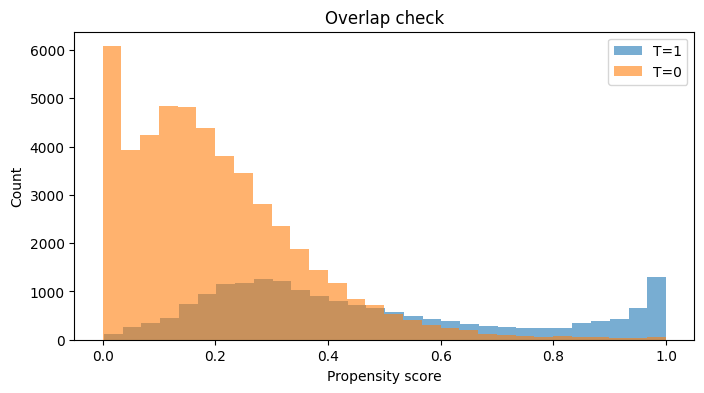

/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_96979/10163874.py:42: RuntimeWarning: invalid value encountered in scalar divide
  smd_raw = (x1.mean() - x0.mean()) / np.sqrt((x1.var() + x0.var())/2)
/var/folders/w9/fgtpv9pd4rdgksslf4vhm2lc0000gn/T/ipykernel_96979/10163874.py:51: RuntimeWarning: invalid value encountered in scalar divide
  smd_w = (m1 - m0) / np.sqrt((v1 + v0)/2)


,var,smd_raw,smd_ipw
0,ruggedness_lag1,0.316723,0.036006
1,population_count_lag1,0.100108,0.005413
2,road_length_tertiary_roads_lag1,0.252614,-0.066684
3,road_length_secondary_roads_lag1,0.234253,0.221841
4,road_length_primary_roads_lag1,0.217145,-0.020134
5,road_length_local_roads_lag1,0.045759,0.013757
6,road_length_highways_lag1,0.069950,0.071066
7,population_density_lag1,-0.074955,0.001188
8,elevation_lag1,0.454372,-0.015362
9,wind_potential_lag1,-0.058210,0.175706


In [5]:

# 識別仮定チェック：オーバーラップ & バランス

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = baseline_df[X_cols]
T = baseline_df[treatment_col].astype(int)

num_cols = list(X.columns)
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols)
])

prop_model = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE))
])

prop_model.fit(X, T)
propensity = prop_model.predict_proba(X)[:,1]
baseline_df['propensity'] = propensity

print(f"Propensity AUC: {roc_auc_score(T, propensity):.3f}")

plt.figure(figsize=(8,4))
plt.hist(propensity[T==1], bins=30, alpha=0.6, label='T=1')
plt.hist(propensity[T==0], bins=30, alpha=0.6, label='T=0')
plt.xlabel('Propensity score')
plt.ylabel('Count')
plt.legend()
plt.title('Overlap check')
plt.show()

# 共変量バランス（標準化平均差）
weights_ipw = T/propensity + (1-T)/(1-propensity)

smd_rows = []
for col in num_cols:
    x1 = baseline_df.loc[T==1, col]
    x0 = baseline_df.loc[T==0, col]
    smd_raw = (x1.mean() - x0.mean()) / np.sqrt((x1.var() + x0.var())/2)
    x1_w = baseline_df.loc[T==1, col]
    x0_w = baseline_df.loc[T==0, col]
    w1 = weights_ipw[T==1]
    w0 = weights_ipw[T==0]
    m1 = np.average(x1_w, weights=w1)
    m0 = np.average(x0_w, weights=w0)
    v1 = np.average((x1_w - m1)**2, weights=w1)
    v0 = np.average((x0_w - m0)**2, weights=w0)
    smd_w = (m1 - m0) / np.sqrt((v1 + v0)/2)
    smd_rows.append({'var': col, 'smd_raw': smd_raw, 'smd_ipw': smd_w})

smd_df = pd.DataFrame(smd_rows)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(smd_df)


In [6]:
# PS trimming + Winsorizing
trim_low, trim_high = 0.05, 0.95
trim_mask = (baseline_df["propensity"] > trim_low) & (baseline_df["propensity"] < trim_high)
trim_df = baseline_df.loc[trim_mask].copy()
print(f"After PS trimming ({trim_low}-{trim_high}): {trim_df.shape}")

# Winsorize outcome (1% tails)
ql = trim_df[y_col].quantile(0.01)
qh = trim_df[y_col].quantile(0.99)
trim_df[y_wins_col] = trim_df[y_col].clip(ql, qh)
print(f"Winsorized Y range: {trim_df[y_wins_col].min():.3f} to {trim_df[y_wins_col].max():.3f}")


After PS trimming (0.05-0.95): (57487, 205)
Winsorized Y range: -4.604 to 2.892


In [ ]:
#ベースライン
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML

Y = trim_df[y_wins_col].to_numpy()
T = trim_df[treatment_col].astype(int).to_numpy()
X = trim_df[X_cols].to_numpy()

est_y = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

est_t = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

cf = CausalForestDML(
    model_y=est_y,
    model_t=est_t,
    discrete_treatment=True,
    cv=3,
    n_estimators=800,
    min_samples_leaf=20,
    min_samples_split=20,
    max_samples=0.45,
    min_balancedness_tol=0.45,
    min_var_fraction_leaf=0.01,
    honest=True,
    inference=True,
    subforest_size=4,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

cf.fit(Y, T, X=X)
ate = cf.ate(X=X)
ci = cf.ate_interval(X=X, alpha=0.05)


ATE (ln(x+0.01)): 0.0185, CI: [-0.0652, 0.1022]
TE mean: 0.0185, median: 0.0161, avg CI width: 0.1367


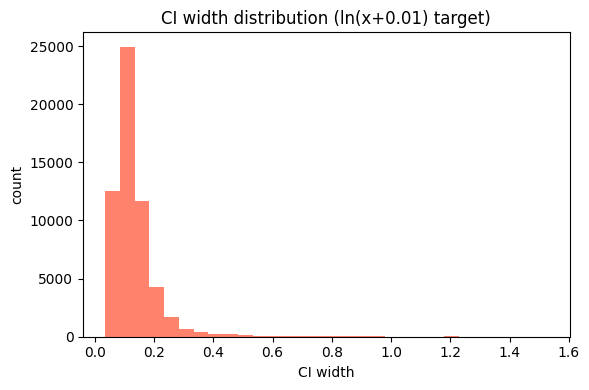

In [11]:
print(f"ATE (ln(x+0.01)): {ate:.4f}, CI: [{float(ci[0]):.4f}, {float(ci[1]):.4f}]")

te_pred = cf.effect(X)
te_ci = cf.effect_interval(X)
ci_width = (te_ci[1] - te_ci[0]).mean()
print(f"TE mean: {np.mean(te_pred):.4f}, median: {np.median(te_pred):.4f}, avg CI width: {ci_width:.4f}")

plt.figure(figsize=(6,4))
plt.hist(te_ci[1] - te_ci[0], bins=30, color='tomato', alpha=0.8)
plt.title('CI width distribution (ln(x+0.01) target)')
plt.xlabel('CI width'); plt.ylabel('count'); plt.tight_layout()

In [7]:
# --- CausalForestDML tuning cell (robust, doc-aligned) ---

import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML

# =========
# 0) 前提チェック（NameError/KeyError防止）
# =========
for name in ["trim_df", "y_wins_col", "treatment_col", "X_cols", "RANDOM_STATE"]:
    if name not in globals():
        raise NameError(f"{name} が未定義です。先に定義してください。")

missing_cols = [c for c in [y_wins_col, treatment_col] + list(X_cols) if c not in trim_df.columns]
if missing_cols:
    raise KeyError(f"trim_df に必要列がありません: {missing_cols}")

# =========
# 1) numpy化 + 欠損/inf を落とす（EconMLは基本的に有限値が前提）
# =========
Y_np = trim_df[y_wins_col].to_numpy(dtype=np.float64)
T_raw = trim_df[treatment_col].to_numpy()  # いったん生
X_np = trim_df[list(X_cols)].to_numpy(dtype=np.float64)

# treatment を数値化（object混入に備える）
T_num = np.asarray(T_raw, dtype=np.float64)

ok = np.isfinite(Y_np) & np.isfinite(T_num) & np.all(np.isfinite(X_np), axis=1)
dropped = int((~ok).sum())
if dropped:
    print(f"[EconML] dropping rows with NaN/inf: {dropped} / {len(ok)}")
Y_np, T_num, X_np = Y_np[ok], T_num[ok], X_np[ok]

# =========
# 2) 0/1処置チェック（離散処置かどうか）
# =========
uniq_t = np.unique(T_num)
is_binary = set(uniq_t.tolist()) <= {0.0, 1.0} and len(uniq_t) <= 2
print("T unique:", uniq_t, "| discrete(binary)?", is_binary)

# binaryならintに（classifier想定）
T_np = T_num.astype(int) if is_binary else T_num.astype(np.float64)

# =========
# 3) nuisance models（固定）
# =========
est_y = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

est_t = (RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=50,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ) if is_binary else
        RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))

# =========
# 4) CausalForestDML（主要引数は公式に合わせる）
# - subforest_size: n_estimators は割り切れる必要あり:contentReference[oaicite:1]{index=1}
# - tune(): 最適パラメータを self にセットするが未fitのまま→ tune後にfit必須:contentReference[oaicite:2]{index=2}
# =========
SUBFOREST_SIZE = 4
N_EST = 800
if N_EST % SUBFOREST_SIZE != 0:
    raise ValueError("n_estimators は subforest_size で割り切れる必要があります。")  # doc

cf = CausalForestDML(
    model_y=est_y,
    model_t=est_t,
    discrete_treatment=bool(is_binary),
    cv=3,
    n_estimators=N_EST,
    min_samples_leaf=20,
    min_samples_split=20,
    max_samples=0.45,     # 0.45 はデフォルト付近（推論も想定）:contentReference[oaicite:3]{index=3}
    honest=True,
    inference=True,
    subforest_size=SUBFOREST_SIZE,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

print("tunable_params:", cf.tunable_params)  # doc上このpropertyがある:contentReference[oaicite:4]{index=4}

# =========
# 5) tune（auto grid）
# デフォルトgridは min_weight_fraction_leaf / max_depth / min_var_fraction_leaf:contentReference[oaicite:5]{index=5}
# =========
cf = cf.tune(Y_np, T_np, X=X_np, params="auto")
print("[EconML] tune done (estimator is still UNFIT; will fit next).")  # doc:contentReference[oaicite:6]{index=6}

# get_params は無い実装があるので getattr で読む（ここがあなたのエラー原因）
picked = {k: getattr(cf, k, None) for k in cf.tunable_params}
print("[EconML] current params snapshot (post-tune):")
for k, v in picked.items():
    print(f"  {k}: {v}")

# =========
# 6) fit（tune後に必須）:contentReference[oaicite:7]{index=7}
# =========
cf.fit(Y_np, T_np, X=X_np)

# =========
# 7) 推定（ATE & CI）: 使えるメソッドにフォールバック
# =========
def _to_float(x):
    return float(np.squeeze(np.asarray(x)))

# ATE
try:
    ate = _to_float(cf.ate(X=X_np))
except TypeError:
    ate = _to_float(cf.ate())
except Exception:
    # 最後の保険：個別効果を平均
    ate


T unique: [0. 1.] | discrete(binary)? True
tunable_params: ['n_estimators', 'criterion', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'min_weight_fraction_leaf', 'min_var_fraction_leaf', 'min_var_leaf_on_val', 'max_features', 'min_impurity_decrease', 'max_samples', 'min_balancedness_tol', 'honest', 'inference', 'fit_intercept', 'subforest_size']
[EconML] tune done (estimator is still UNFIT; will fit next).
[EconML] current params snapshot (post-tune):
  n_estimators: 800
  criterion: mse
  max_depth: None
  min_samples_split: 20
  min_samples_leaf: 20
  min_weight_fraction_leaf: 0.0001
  min_var_fraction_leaf: 0.001
  min_var_leaf_on_val: False
  max_features: auto
  min_impurity_decrease: 0.0
  max_samples: 0.45
  min_balancedness_tol: 0.45
  honest: True
  inference: True
  fit_intercept: True
  subforest_size: 4


GATE by institution_index_lag1 quantiles (q=3)  |  X_het_cols=['institution_index_lag1']


,group,n,inst_min,inst_median,inst_max,GATE_log,CI95_log_lo,CI95_log_hi,GATE_pct,CI95_pct_lo,CI95_pct_hi
0,Q1,23755,-2.149969,-0.118243,-0.062262,0.039010,-0.081164,0.159185,3.978138,-7.795718,17.255434
1,Q2,16397,-0.050993,-0.012349,0.073687,0.018307,-0.020660,0.057274,1.847552,-2.044790,5.894560
2,Q3,17335,0.144034,0.265868,1.897483,0.007361,-0.034080,0.048802,0.738785,-3.350595,5.001191


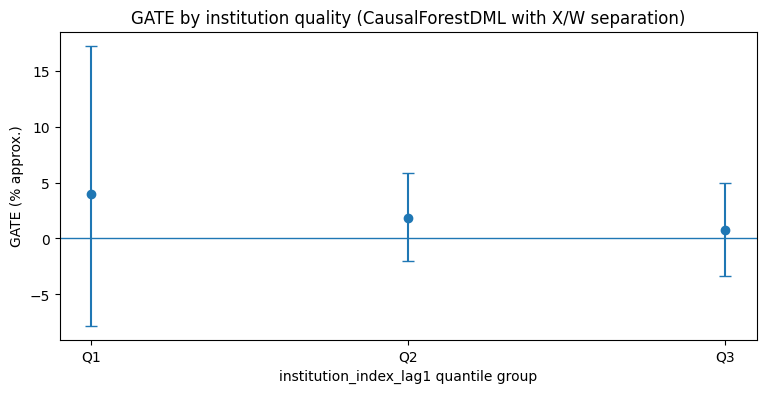

Corr(median institution_index_lag1, GATE%): -0.907


In [8]:
# --- GATE by institution quality (with X/W separation) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML

Y_np = trim_df[y_wins_col].to_numpy(np.float32)
T_np = trim_df[treatment_col].astype(int).to_numpy()

X_het_cols = ["institution_index_lag1"]
W_cols = [c for c in X_cols if c not in set(X_het_cols)]

X_het = trim_df[X_het_cols].to_numpy(np.float32)
W = trim_df[W_cols].to_numpy(np.float32)

if "cf_sep" not in globals():
    est_y = RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    est_t = RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=50,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    cf_sep = CausalForestDML(
        model_y=est_y,
        model_t=est_t,
        discrete_treatment=True,
        cv=3,
        n_estimators=800,
        min_samples_leaf=20,
        min_samples_split=20,
        max_samples=0.45,
        honest=True,
        inference=True,
        subforest_size=4,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    cf_sep.fit(Y_np, T_np, X=X_het, W=W)

inst_col = X_het_cols[0]
if inst_col not in trim_df.columns:
    raise KeyError(f"{inst_col} is not in trim_df")

inst = trim_df[inst_col].astype(float)
mask = inst.notna().to_numpy()
X_het_m = X_het[mask]
inst_m = inst.to_numpy()[mask]

q = 3
labels = [f"Q{i}" for i in range(1, q + 1)]
inst_bin = pd.qcut(inst_m, q=q, labels=labels, duplicates="drop")

rows = []
for g in labels:
    idx = (inst_bin == g)
    n_g = int(idx.sum())
    if n_g == 0:
        continue

    X_g = X_het_m[idx]

    gate_log = float(cf_sep.ate(X=X_g))
    ci_log = cf_sep.ate_interval(X=X_g, alpha=0.05)
    lo_log, hi_log = float(ci_log[0]), float(ci_log[1])

    gate_pct = (np.exp(gate_log) - 1.0) * 100.0
    lo_pct   = (np.exp(lo_log) - 1.0) * 100.0
    hi_pct   = (np.exp(hi_log) - 1.0) * 100.0

    vals = inst_m[idx]
    rows.append({
        "group": g,
        "n": n_g,
        "inst_min": float(np.min(vals)),
        "inst_median": float(np.median(vals)),
        "inst_max": float(np.max(vals)),
        "GATE_log": gate_log,
        "CI95_log_lo": lo_log,
        "CI95_log_hi": hi_log,
        "GATE_pct": gate_pct,
        "CI95_pct_lo": lo_pct,
        "CI95_pct_hi": hi_pct,
    })

gate_df = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)

print(f"GATE by {inst_col} quantiles (q={q})  |  X_het_cols={X_het_cols}")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(gate_df)

plt.figure(figsize=(9, 4))
x = np.arange(len(gate_df))
y = gate_df["GATE_pct"].to_numpy()

yerr_lo = y - gate_df["CI95_pct_lo"].to_numpy()
yerr_hi = gate_df["CI95_pct_hi"].to_numpy() - y

plt.errorbar(x, y, yerr=[yerr_lo, yerr_hi], fmt='o', capsize=4)
plt.axhline(0, linewidth=1)
plt.xticks(x, gate_df["group"].tolist())
plt.xlabel(f"{inst_col} quantile group")
plt.ylabel("GATE (% approx.)")
plt.title("GATE by institution quality (CausalForestDML with X/W separation)")
plt.show()

if len(gate_df) >= 3:
    corr = np.corrcoef(gate_df["inst_median"], gate_df["GATE_pct"])[0, 1]
    print(f"Corr(median {inst_col}, GATE%): {corr:.3f}")


In [1]:
# ============================================================
# Fast ADM2 cluster bootstrap CI for ATE / GATE (percentile)
#  - No refit: reuse fitted cf, bootstrap cluster-level aggregates
# ============================================================

import numpy as np
import pandas as pd

# ---- config ----
cluster_col = "GID_2"
gate_var = "institution_index_lag1"  # change if needed
n_gate_bins = 5
B = 300
alpha = 0.05
seed = 123

# ---- checks ----
for name in ["trim_df", "cf", "X_cols"]:
    if name not in globals():
        raise NameError(f"{name} is not defined. Run CF fit cell first.")

df = trim_df.copy()
if cluster_col not in df.columns:
    raise KeyError(f"{cluster_col} not in trim_df")

# ---- effect once ----
X_eval = df[X_cols].to_numpy()
tau = np.asarray(cf.effect(X_eval, T0=0, T1=1)).reshape(-1)

df_eval = df[[cluster_col]].copy()
df_eval["_tau"] = tau

# ---- ATE point estimate ----
ate_hat = float(df_eval["_tau"].mean())

# ---- cluster-level aggregates ----
cluster_stats = df_eval.groupby(cluster_col)["_tau"].agg(["sum", "count"]).reset_index()
clusters = cluster_stats[cluster_col].to_numpy()
sum_tau = cluster_stats["sum"].to_numpy()
n_tau = cluster_stats["count"].to_numpy()
G = len(clusters)

rng = np.random.default_rng(seed)
idx = rng.integers(0, G, size=(B, G))
ate_boot = sum_tau[idx].sum(axis=1) / n_tau[idx].sum(axis=1)
ate_ci = np.nanquantile(ate_boot, [alpha / 2, 1 - alpha / 2])

print(f"ATE (log): {ate_hat:.6f}")
print(f"ATE {int((1-alpha)*100)}% CI (cluster bootstrap): [{ate_ci[0]:.6f}, {ate_ci[1]:.6f}]")

# ---- GATE (optional) ----
if gate_var in df.columns:
    df_gate = df[[cluster_col, gate_var]].copy()
    df_gate["_tau"] = tau
    df_gate = df_gate.dropna(subset=[gate_var])

    df_gate["_gate_bin"] = pd.qcut(df_gate[gate_var], q=n_gate_bins,
                                   labels=False, duplicates="drop")
    gate_bins = sorted(df_gate["_gate_bin"].dropna().unique().tolist())
    gate_hat = df_gate.groupby("_gate_bin")["_tau"].mean().reindex(gate_bins)

    cluster_index = pd.Index(clusters)
    gate_rows = []

    # precompute cluster-level sums/counts for each bin
    gate_sum = {}
    gate_n = {}
    for b in gate_bins:
        tmp = df_gate[df_gate["_gate_bin"] == b].groupby(cluster_col)["_tau"].agg(["sum", "count"])
        sum_arr = tmp["sum"].reindex(cluster_index, fill_value=0).to_numpy()
        n_arr = tmp["count"].reindex(cluster_index, fill_value=0).to_numpy()
        gate_sum[b] = sum_arr
        gate_n[b] = n_arr

    for b in gate_bins:
        num = gate_sum[b][idx].sum(axis=1)
        den = gate_n[b][idx].sum(axis=1)
        boot = np.where(den > 0, num / den, np.nan)
        ci = np.nanquantile(boot, [alpha / 2, 1 - alpha / 2])

        gate_rows.append({
            "gate_bin": b,
            "GATE_log": float(gate_hat.loc[b]),
            "CI95_log_lo": float(ci[0]),
            "CI95_log_hi": float(ci[1]),
        })

    gate_ci_df = pd.DataFrame(gate_rows)
    display(gate_ci_df)
else:
    print(f"[INFO] gate_var '{gate_var}' not found -> skip GATE.")


NameError: trim_df is not defined. Run CF fit cell first.

In [14]:
# ===== Modified Causal Forest (MCF) をインストール =====
# ※ Python >= 3.8 推奨

#%pip install --upgrade pip
%pip install mcf


Note: you may need to restart the kernel to use updated packages.


train_df shape: (57487, 206)
Resolved y_col: night_lights_ln001_wins -> night_lights_ln001_wins
Resolved d_col: mine_presence_expanded_v2_lag1 -> mine_presence_expanded_v2_lag1
x_ord hit=96  | W_miss=0 X_miss=0

ModifiedCausalForest.__init__ signature (this env):
(self, var_d_name=None, var_id_name=None, var_w_name=None, var_x_balance_name_ord=None, var_x_balance_name_unord=None, var_x_name_always_in_ord=None, var_x_name_always_in_unord=None, var_x_name_remain_ord=None, var_x_name_remain_unord=None, var_x_name_ord=None, var_x_name_unord=None, var_y_name=None, var_y_tree_name=None, var_z_name_list=None, var_z_name_ord=None, var_z_name_unord=None, p_atet=False, p_gatet=False, p_bgate=False, p_cbgate=False, cf_boot=1000, lc_yes=True, cf_alpha_reg_grid=1, cf_alpha_reg_max=0.15, cf_alpha_reg_min=0.05, cf_chunks_maxsize=None, cf_n_min_grid=1, cf_n_min_max=None, cf_n_min_min=None, cf_n_min_treat=None, cf_nn_main_diag_only=False, cf_m_grid=1, cf_m_random_poisson=True, cf_m_share_max=0.6, cf_m_

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



Matched outcomes

Short info on data used:
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14733 entries, 0 to 14732
Data columns (total 2 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   NIGHT_LIGHTS_LN001_WINS_LC_NN0  14733 non-null  float64
 1   NIGHT_LIGHTS_LN001_WINS_LC_NN1  14733 non-null  float64
dtypes: float64(2)
memory usage: 230.3 KB

       NIGHT_LIGHTS_LN001_WINS_LC_NN0  NIGHT_LIGHTS_LN001_WINS_LC_NN1
count                    14733.000000                    14733.000000
mean                         0.004395                        0.010480
std                          0.359100                        0.259814
min                         -2.223188                       -1.464553
25%                         -0.190524                       -0.126759
50%                         -0.004304   

KeyboardInterrupt: 

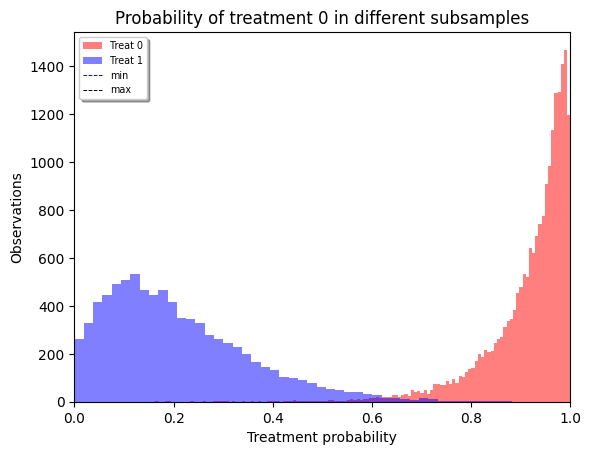

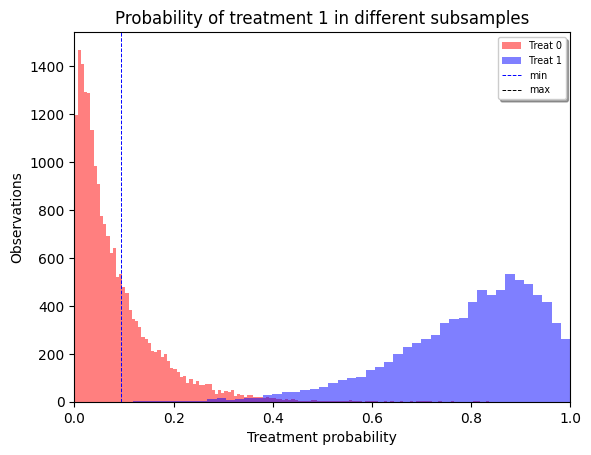

In [ ]:
# # --- MCF: common support ON + CI表示（mcf 0.5.1 互換・大文字吸収・CI計算つき） ---

# import numpy as np
# import pandas as pd
# import inspect
# from statistics import NormalDist
# from mcf import ModifiedCausalForest

# # ----------------------------
# # 0) 前提チェック
# # ----------------------------
# for name in ["trim_df", "y_wins_col", "treatment_col", "W_cols", "X_het_cols"]:
#     if name not in globals():
#         raise NameError(f"{name} が未定義です。")

# train_df = trim_df.copy()
# pred_df  = train_df

# # ----------------------------
# # 1) カラム名の「大文字/小文字」吸収（重要）
# # ----------------------------
# def _build_case_insensitive_map(cols):
#     # lower -> actual（同じlowerが複数あるのは稀なので先勝ち）
#     mp = {}
#     for c in cols:
#         lc = str(c).lower()
#         if lc not in mp:
#             mp[lc] = c
#     return mp

# _colmap = _build_case_insensitive_map(train_df.columns)

# def _resolve_col(name: str):
#     if name in train_df.columns:
#         return name
#     hit = _colmap.get(str(name).lower())
#     if hit is not None:
#         return hit
#     return None

# def _resolve_list(names):
#     out, miss = [], []
#     for n in names:
#         r = _resolve_col(n)
#         if r is None:
#             miss.append(n)
#         else:
#             out.append(r)
#     return out, miss

# # 元の指定（あなたのノートブック側の変数名）
# y_col_raw = y_wins_col
# d_col_raw = treatment_col
# W_ord_raw = list(W_cols) if W_cols is not None else []
# X_ord_raw = list(X_het_cols) if X_het_cols is not None else []

# # 実データ側の列名へ解決
# y_col = _resolve_col(y_col_raw)
# d_col = _resolve_col(d_col_raw)
# if y_col is None:
#     raise KeyError(f"y_col が train_df に見つかりません: {y_col_raw}")
# if d_col is None:
#     raise KeyError(f"d_col が train_df に見つかりません: {d_col_raw}")

# W_ord, W_miss = _resolve_list(W_ord_raw)
# X_ord, X_miss = _resolve_list(X_ord_raw)

# # covariates = W + X_het（あなたの設計）
# x_ord = sorted(set(W_ord + X_ord))
# x_unord = []  # 今回は未使用

# print("train_df shape:", train_df.shape)
# print("Resolved y_col:", y_col_raw, "->", y_col)
# print("Resolved d_col:", d_col_raw, "->", d_col)
# print(f"x_ord hit={len(x_ord)}  | W_miss={len(W_miss)} X_miss={len(X_miss)}")
# if W_miss[:10] or X_miss[:10]:
#     print("Example missing W cols:", W_miss[:10])
#     print("Example missing X cols:", X_miss[:10])

# if len(x_ord) == 0:
#     raise ValueError("説明変数が0本です（W_cols / X_het_cols がデータ列と一致していません）。")

# # ----------------------------
# # 2) 受け取れる引数だけ通す（0.5.1互換）
# # ----------------------------
# def _filter_kwargs_for_init(cls, kwargs: dict):
#     sig = inspect.signature(cls.__init__)
#     allowed = set(sig.parameters.keys())
#     filtered = {k: v for k, v in kwargs.items() if (k in allowed and v is not None)}
#     dropped = sorted([k for k in kwargs.keys() if k not in allowed])
#     return filtered, dropped, sig

# # ----------------------------
# # 3) 推奨：CI/SE 設定（重いのでノブを用意）
# # ----------------------------
# CI_LEVEL = 0.95

# # ブートストラップSE（重い）：False/0 にすれば軽くなる
# BOOT_ATE  = False   # False / 0 / 199 / 500 など
# BOOT_GATE = False   # GATEのブートストラップは特に重くなりがち

# # パネル（ADM2×year）ならクラスタSEにしたい → cluster列を指定
# CLUSTER_COL_RAW = "GID_2"
# cluster_col = None  # 大文字吸収
# USE_CLUSTER = False

# raw_kwargs = dict(
#     # 必須
#     var_y_name=y_col,
#     var_d_name=d_col,
#     var_x_name_ord=x_ord,
#     var_x_name_unord=None,

#     # heterogeneity用（GATEに使う変数群）
#     var_z_name_ord=(X_ord if len(X_ord) > 0 else None),
#     var_z_name_unord=None,

#     # common support
#     cs_type=1,
#     cs_max_del_train=0.90,


#     # 出力
#     gen_outpath="./mcf_out_cs_on_permissive",
#     gen_output_type=2,
#     _int_with_output=True,
#     _int_verbose=True,
#     _int_show_plots=False,

#     # ===== CI/SEまわり =====
#     p_ci_level=CI_LEVEL,                # 信頼水準 :contentReference[oaicite:5]{index=5}
#     p_ate_no_se_only=False,             # ATEだけでSE不要…にしない :contentReference[oaicite:6]{index=6}

#     # ブートストラップSE（指定方法は公式説明あり） :contentReference[oaicite:7]{index=7}
#     p_se_boot_ate=BOOT_ATE if BOOT_ATE else False,
#     p_se_boot_gate=BOOT_GATE if BOOT_GATE else False,

#     # IATEのSEが欲しければ True（ただし激重＆出力も巨大）
#     p_iate_se=False                    # IATE SE :contentReference[oaicite:8]{index=8}

# )

# kwargs, dropped, sig = _filter_kwargs_for_init(ModifiedCausalForest, raw_kwargs)

# print("\nModifiedCausalForest.__init__ signature (this env):")
# print(sig)
# if dropped:
#     print("\n[INFO] この環境では未対応のため自動で無視した引数:", dropped)
# if USE_CLUSTER:
#     print(f"[INFO] cluster SE enabled: var_cluster_name='{cluster_col}'")
# else:
#     print("[INFO] cluster SE disabled (cluster col not found).")

# mcf_cs = ModifiedCausalForest(**kwargs)

# # ----------------------------
# # 4) CS落ち率（出力にDataFrameがあれば拾う）
# # ----------------------------
# def _infer_cs_flag_col(df: pd.DataFrame) -> str:
#     for c in df.columns:
#         lc = str(c).lower()
#         if ("support" in lc) or ("common" in lc) or (lc in ["cs", "in_support", "common_support"]):
#             s = df[c].dropna()
#             if s.dtype == bool:
#                 return c
#             try:
#                 u = set(pd.unique(s))
#                 if u.issubset({0, 1}):
#                     return c
#             except TypeError:
#                 pass

#     candidates = []
#     for c in df.columns:
#         lc = str(c).lower()
#         if "id" in lc or "gid" in lc:
#             continue
#         s = df[c].dropna()
#         if s.dtype == bool:
#             candidates.append(c)
#             continue
#         try:
#             u = set(pd.unique(s))
#             if u.issubset({0, 1}) and len(u) <= 2:
#                 candidates.append(c)
#         except TypeError:
#             pass

#     if not candidates:
#         raise ValueError(f"common support のフラグ列を推定できません。columns={list(df.columns)}")
#     return candidates[0]

# def _print_drop_stats(cs_df: pd.DataFrame, label: str):
#     flag_col = _infer_cs_flag_col(cs_df)
#     inside = cs_df[flag_col].astype(int)
#     n_total = len(inside)
#     n_in = int(inside.sum())
#     n_out = int(n_total - n_in)
#     pct_out = 100.0 * (n_out / n_total) if n_total > 0 else np.nan
#     print(f"[{label}] flag='{flag_col}' | total={n_total:,} kept={n_in:,} dropped={n_out:,} ({pct_out:.2f}%)")

# def _as_dict(res):
#     if isinstance(res, dict):
#         return res
#     if hasattr(res, "items") and callable(res.items):
#         try:
#             return dict(res.items())
#         except Exception:
#             return {}
#     return {}

# def _find_dfs(res_dict: dict):
#     out = []
#     for k, v in res_dict.items():
#         if isinstance(v, pd.DataFrame) and not v.empty:
#             out.append((k, v))
#     return out

# # ----------------------------
# # 5) train / predict
# # ----------------------------

# # --- MCF に渡す df を「必要列だけ」「全部数値」にする（np.isnan落ち回避） ---

# # 使う列だけ（y, d, covariates, heterogeneity, cluster）
# use_cols = [y_col, d_col] + list(x_ord) + (list(X_ord) if X_ord else [])
# if "cluster_col" in globals() and cluster_col is not None:
#     use_cols.append(cluster_col)

# # 重複除去 + 存在チェック
# use_cols = [c for c in dict.fromkeys(use_cols) if c in train_df.columns]

# train_df_mcf = train_df[use_cols].copy()

# # 念のため：object/string が残ってたら落とす（本来はここで 0 件になるのが理想）
# obj_cols = train_df_mcf.select_dtypes(include=["object", "string"]).columns.tolist()
# if obj_cols:
#     raise TypeError(f"MCFに渡すdfに object/string 列が残っています: {obj_cols}")

# # pandas の nullable Int64 なども object 化の原因になりがちなので、共変量は float に寄せる
# for c in train_df_mcf.columns:
#     if c == d_col:
#         continue
#     train_df_mcf[c] = pd.to_numeric(train_df_mcf[c], errors="coerce").astype(np.float32)

# # treatment は離散のまま（欠損は落とす）
# train_df_mcf[d_col] = pd.to_numeric(train_df_mcf[d_col], errors="coerce")
# train_df_mcf = train_df_mcf.dropna(subset=[d_col])  # treatment欠損は許容しない
# train_df_mcf[d_col] = train_df_mcf[d_col].astype(np.int16)

# print("train_df_mcf shape:", train_df_mcf.shape)
# print("train_df_mcf dtype counts:\n", train_df_mcf.dtypes.astype(str).value_counts())
# print("train_df_mcf numpy dtype:", train_df_mcf.to_numpy().dtype)

# train_res = mcf_cs.train(train_df_mcf)
# pred_res  = mcf_cs.predict(train_df_mcf)  # まずは同じdfでOK
# train_dict = _as_dict(train_res)
# print("\n--- train() done ---")
# if train_dict:
#     for k, df_ in _find_dfs(train_dict):
#         try:
#             _print_drop_stats(df_, f"TRAIN({k})")
#         except Exception:
#             pass

# pred_res  = mcf_cs.predict(train_df_mcf)  # まずは同じdfでOK
# pred_dict = _as_dict(pred_res)
# print("\n--- predict() done ---")

# # ----------------------------
# # 6) ATE/GATEを拾って「CIを自分で計算して表示」
# # ----------------------------
# def _z_from_level(level: float) -> float:
#     # two-sided
#     return NormalDist().inv_cdf(0.5 + level / 2.0)

# Z = _z_from_level(CI_LEVEL)

# def _ci_from_se(point, se):
#     lo = point - Z * se
#     hi = point + Z * se
#     return lo, hi

# # ATE
# ate = pred_dict.get("ate")
# ate_se = pred_dict.get("ate_se")

# print("\nATE raw:\n", ate)
# print("ATE_se raw:\n", ate_se)

# # よくあるケース：float / 0-d array
# try:
#     if ate is not None and ate_se is not None:
#         ate_val = float(np.asarray(ate).reshape(-1)[0])
#         se_val  = float(np.asarray(ate_se).reshape(-1)[0])
#         lo, hi = _ci_from_se(ate_val, se_val)
#         print(f"\nATE ({CI_LEVEL*100:.1f}% CI): {ate_val:.6f}  [{lo:.6f}, {hi:.6f}]")
# except Exception as e:
#     print("[WARN] ATE CI computation failed:", e)

# # GATE
# gate = pred_dict.get("gate")
# gate_se = pred_dict.get("gate_se")

# print("\nGATE raw:\n", gate)
# print("GATE_se raw:\n", gate_se)

# # DataFrame想定でCI列を付ける（列名は環境で違うので “最初の数値列” を推定）
# def _ensure_df(x):
#     if x is None:
#         return None
#     if isinstance(x, pd.DataFrame):
#         return x.copy()
#     # dict/list等ならDataFrame化を試みる
#     try:
#         return pd.DataFrame(x).copy()
#     except Exception:
#         return None

# gate_df = _ensure_df(gate)
# gate_se_df = _ensure_df(gate_se)

# if gate_df is not None and gate_se_df is not None:
#     # 数値列を雑に推定（最初のfloat列）
#     gate_num_cols = [c for c in gate_df.columns if pd.api.types.is_numeric_dtype(gate_df[c])]
#     se_num_cols   = [c for c in gate_se_df.columns if pd.api.types.is_numeric_dtype(gate_se_df[c])]
#     if gate_num_cols and se_num_cols:
#         gcol = gate_num_cols[0]
#         scol = se_num_cols[0]
#         out = gate_df.copy()
#         out["se"] = gate_se_df[scol].to_numpy()
#         out["ci_lo"] = out[gcol] - Z * out["se"]
#         out["ci_hi"] = out[gcol] + Z * out["se"]
#         print(f"\nGATE with {CI_LEVEL*100:.1f}% CI (using point='{gcol}', se='{scol}'):")
#         display(out)
#     else:
#         print("[WARN] GATE/GATE_se に数値列が見つからず、CIを作れませんでした。")
# else:
#     print("[INFO] gate or gate_se is None (GATEのSEが計算されていない/返っていない可能性)。")


In [ ]:
from importlib.metadata import version

print("mcf distribution version:", version("mcf"))


mcf distribution version: 0.5.1
